# 3D k-Wave — Real NIfTI Skull
Uses `skull_mask.nii` (0.5 mm isotropic) as the skull bone.  
Brain interior is inferred from the skull geometry (no separate brain segmentation needed).

| Tissue | c (m/s) | ρ (kg/m³) |
|--------|---------|----------|
| Water  | 1482    | 1000     |
| Skull  | 2900    | 1900     |
| Brain  | 1560    | 1040     |

## Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import ndimage

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

## Acoustic Parameters

In [17]:
freq      = 500e3      # Hz

c_water   = 1482.0;  rho_water  = 1000.0
c_skull   = 2900.0;  rho_skull  = 1900.0
c_brain   = 1560.0;  rho_brain  = 1040.0

print(f'Frequency : {freq/1e3:.0f} kHz')
print(f'Wavelength in water : {c_water/freq*1e3:.2f} mm')

Frequency : 500 kHz
Wavelength in water : 2.96 mm


## Step 1 — Load NIfTI Skull
Loads `skull_mask.nii` and pads Z to make a cubic grid.  
Prints shape, voxel size, and affine so alignment issues are visible immediately.

In [19]:
# ── Load skull ───────────────────────────────────────────────────────────────
skull_nii = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\skull_mask.nii')
skull_raw = skull_nii.get_fdata().astype(bool)
vox_mm    = np.array(skull_nii.header.get_zooms()[:3])
dx        = float(vox_mm[0]) * 1e-3   # m

# ── Load brain ───────────────────────────────────────────────────────────────
brain_nii = nib.load(r'C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii')
brain_raw = brain_nii.get_fdata().astype(bool)

print(f'Skull : {skull_raw.shape}   voxel={vox_mm} mm')
print(f'Brain : {brain_raw.shape}')
print(f'\nSkull affine:\n{skull_nii.affine}')
print(f'\nBrain affine:\n{brain_nii.affine}')

# ── Affine check — resample if needed ────────────────────────────────────────
if np.allclose(skull_nii.affine, brain_nii.affine, atol=1e-3):
    print('\nAffines match — no resampling needed.')
else:
    print('\nAffine mismatch — resampling brain into skull space ...')
    from nibabel.processing import resample_from_to
    brain_raw = resample_from_to(brain_nii, skull_nii, order=0).get_fdata().astype(bool)
    print(f'Resampled brain shape : {brain_raw.shape}')

# ── Pad both to a cubic 256³ grid ────────────────────────────────────────────
def pad_to_cube(vol, target=256):
    for ax in range(3):
        deficit = max(0, target - vol.shape[ax])
        pad = [(0,0)]*3
        pad[ax] = (deficit//2, deficit - deficit//2)
        vol = np.pad(vol, pad, mode='constant')
    return vol

skull_pad = pad_to_cube(skull_raw)
brain_pad = pad_to_cube(brain_raw)
brain_pad = brain_pad & ~skull_pad   # remove any skull–brain overlap

Nx, Ny, Nz = skull_pad.shape
print(f'\nPadded : {skull_pad.shape}  ({Nx*dx*1e3:.0f} × {Ny*dx*1e3:.0f} × {Nz*dx*1e3:.0f} mm)')
print(f'Skull voxels : {skull_pad.sum():,}')
print(f'Brain voxels : {brain_pad.sum():,}')
print(f'Water voxels : {(~skull_pad & ~brain_pad).sum():,}')

Skull : (256, 256, 208)   voxel=[0.5 0.5 0.5] mm
Brain : (256, 256, 208)

Skull affine:
[[ -0.           0.           0.5        -52.35240936]
 [ -0.5         -0.          -0.          18.13077545]
 [  0.          -0.5          0.          41.24769592]
 [  0.           0.           0.           1.        ]]

Brain affine:
[[ -0.           0.           0.5        -52.35240936]
 [ -0.5         -0.          -0.          18.13077545]
 [  0.          -0.5          0.          41.24769592]
 [  0.           0.           0.           1.        ]]

Affines match — no resampling needed.

Padded : (256, 256, 256)  (128 × 128 × 128 mm)
Skull voxels : 905,935
Brain voxels : 639,425
Water voxels : 15,231,856


Brain bounding box:
  X: [117–221]  Y: [65–204]  Z: [71–178]
  Centre voxel : (169, 134, 124)
  Volume       : 639,425 voxels  (79.9 cm³)


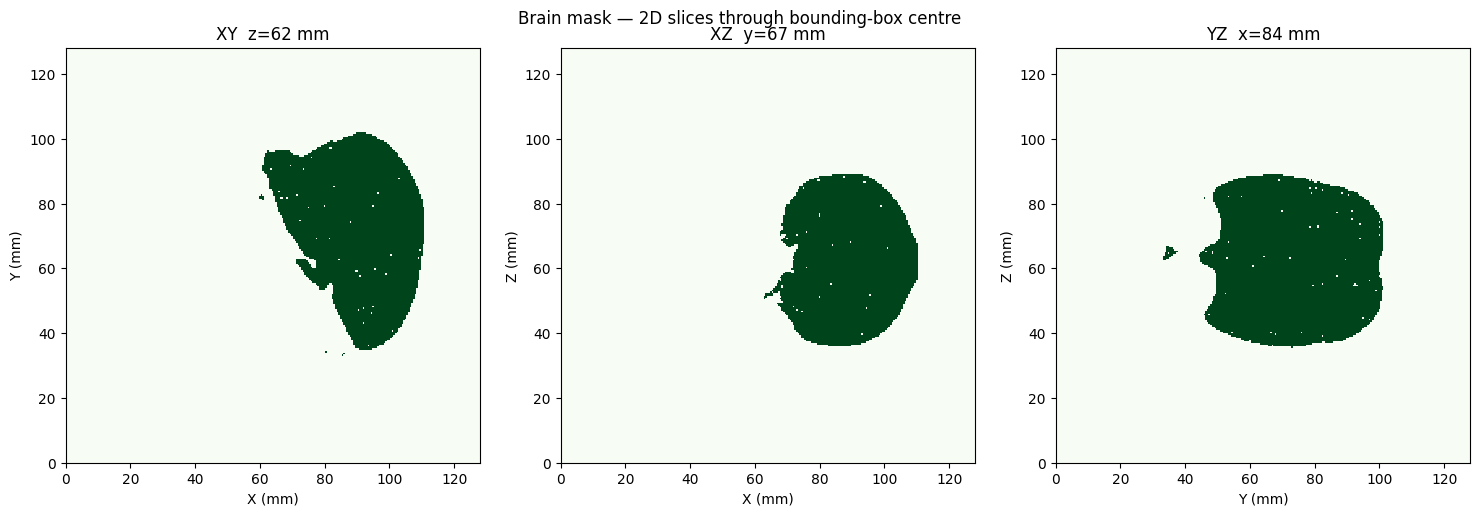


Brain surface mesh: 22,463 vertices, 44,914 faces


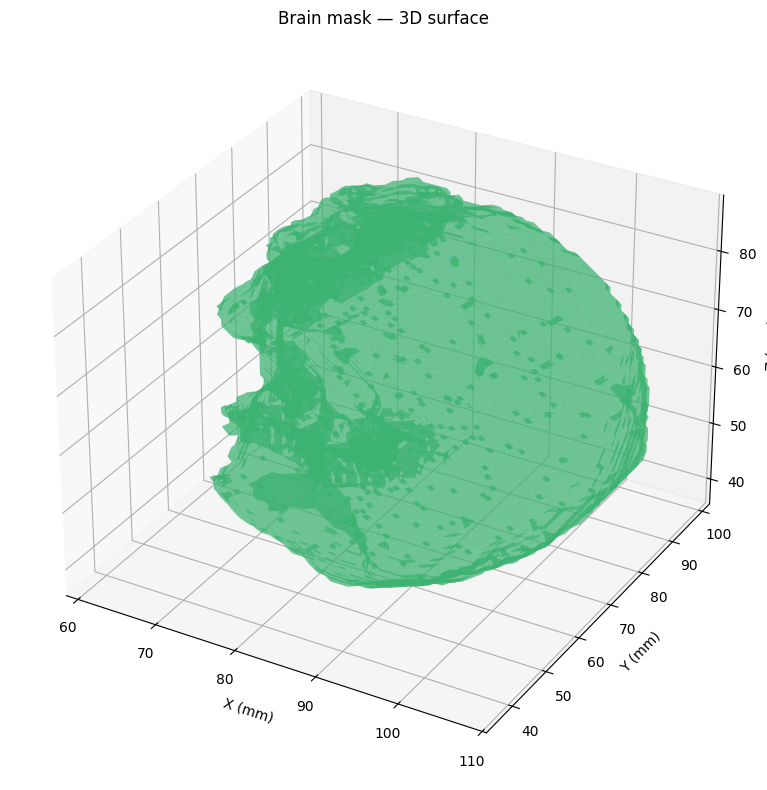

Saved brain_2d.png and brain_3d.png


In [20]:
# ── Brain-only diagnostic: 2D slices + 3D surface ────────────────────────────
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

b_idx = np.argwhere(brain_pad)
cxb = int((b_idx[:,0].min() + b_idx[:,0].max()) // 2)
cyb = int((b_idx[:,1].min() + b_idx[:,1].max()) // 2)
czb = int((b_idx[:,2].min() + b_idx[:,2].max()) // 2)

ex = [0, Nx*dx*1e3];  ey = [0, Ny*dx*1e3];  ez = [0, Nz*dx*1e3]

print(f'Brain bounding box:')
print(f'  X: [{b_idx[:,0].min()}–{b_idx[:,0].max()}]  '
      f'Y: [{b_idx[:,1].min()}–{b_idx[:,1].max()}]  '
      f'Z: [{b_idx[:,2].min()}–{b_idx[:,2].max()}]')
print(f'  Centre voxel : ({cxb}, {cyb}, {czb})')
print(f'  Volume       : {brain_pad.sum():,} voxels  ({brain_pad.sum()*dx**3*1e6:.1f} cm³)')

# 2D slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
kw2 = dict(origin='lower', cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
axes[0].imshow(brain_pad[:, :, czb].T.astype(float), extent=ex+ey, **kw2)
axes[0].set(title=f'XY  z={czb*dx*1e3:.0f} mm', xlabel='X (mm)', ylabel='Y (mm)')
axes[1].imshow(brain_pad[:, cyb, :].T.astype(float), extent=ex+ez, **kw2)
axes[1].set(title=f'XZ  y={cyb*dx*1e3:.0f} mm', xlabel='X (mm)', ylabel='Z (mm)')
axes[2].imshow(brain_pad[cxb, :, :].T.astype(float), extent=ey+ez, **kw2)
axes[2].set(title=f'YZ  x={cxb*dx*1e3:.0f} mm', xlabel='Y (mm)', ylabel='Z (mm)')
plt.suptitle('Brain mask — 2D slices through bounding-box centre', fontsize=12)
plt.tight_layout()
plt.savefig('brain_2d.png', dpi=150)
plt.show()

# 3D surface
verts, faces, _, _ = measure.marching_cubes(brain_pad.astype(np.float32), level=0.5, step_size=2)
verts_mm = verts * dx * 1e3
print(f'\nBrain surface mesh: {len(verts_mm):,} vertices, {len(faces):,} faces')

fig = plt.figure(figsize=(9, 8))
ax  = fig.add_subplot(111, projection='3d')
mesh = Poly3DCollection(verts_mm[faces], alpha=0.5, linewidth=0)
mesh.set_facecolor('#3cb371')
ax.add_collection3d(mesh)
ax.set_xlim(verts_mm[:,0].min(), verts_mm[:,0].max())
ax.set_ylim(verts_mm[:,1].min(), verts_mm[:,1].max())
ax.set_zlim(verts_mm[:,2].min(), verts_mm[:,2].max())
ax.set_xlabel('X (mm)');  ax.set_ylabel('Y (mm)');  ax.set_zlabel('Z (mm)')
ax.set_title('Brain mask — 3D surface')
plt.tight_layout()
plt.savefig('brain_3d.png', dpi=150)
plt.show()
print('Saved brain_2d.png and brain_3d.png')

## Step 2 — Brain Mask Sanity Check\nVerifies the brain mask loaded in Step 1 is consistent with the skull:\n- zero overlap between brain and skull voxels\n- brain bounding box sits inside skull bounding box\n- reasonable brain volume (~1000–1500 cm³)

In [21]:
# Use the 3D Slicer brain mask loaded in Step 1
b_idx = np.argwhere(brain_pad)
s_idx = np.argwhere(skull_pad)

print(f'Brain voxels : {brain_pad.sum():,}  ({brain_pad.sum()*dx**3*1e6:.1f} cm³)')
print(f'Skull voxels : {skull_pad.sum():,}  ({skull_pad.sum()*dx**3*1e6:.1f} cm³)')
print(f'Overlap      : {(brain_pad & skull_pad).sum()}  (should be 0)\n')

for i, name in enumerate(['X', 'Y', 'Z']):
    b_lo, b_hi = b_idx[:,i].min(), b_idx[:,i].max()
    s_lo, s_hi = s_idx[:,i].min(), s_idx[:,i].max()
    status = 'OK' if b_lo >= s_lo and b_hi <= s_hi else 'WARNING: brain outside skull'
    print(f'  {name}: brain=[{b_lo}–{b_hi}]  skull=[{s_lo}–{s_hi}]  {status}')

Brain voxels : 639,425  (79.9 cm³)
Skull voxels : 905,935  (113.2 cm³)
Overlap      : 0  (should be 0)

  X: brain=[117–221]  skull=[20–228]  OK
  Y: brain=[65–204]  skull=[0–244]  OK
  Z: brain=[71–178]  skull=[32–222]  OK


## Step 3 — Geometry Diagnostic
2D colour-coded tissue map (water=navy, brain=green, skull=gold) sliced through the skull bounding-box centre.  
3D surface render (marching cubes) with skull and brain overlaid.

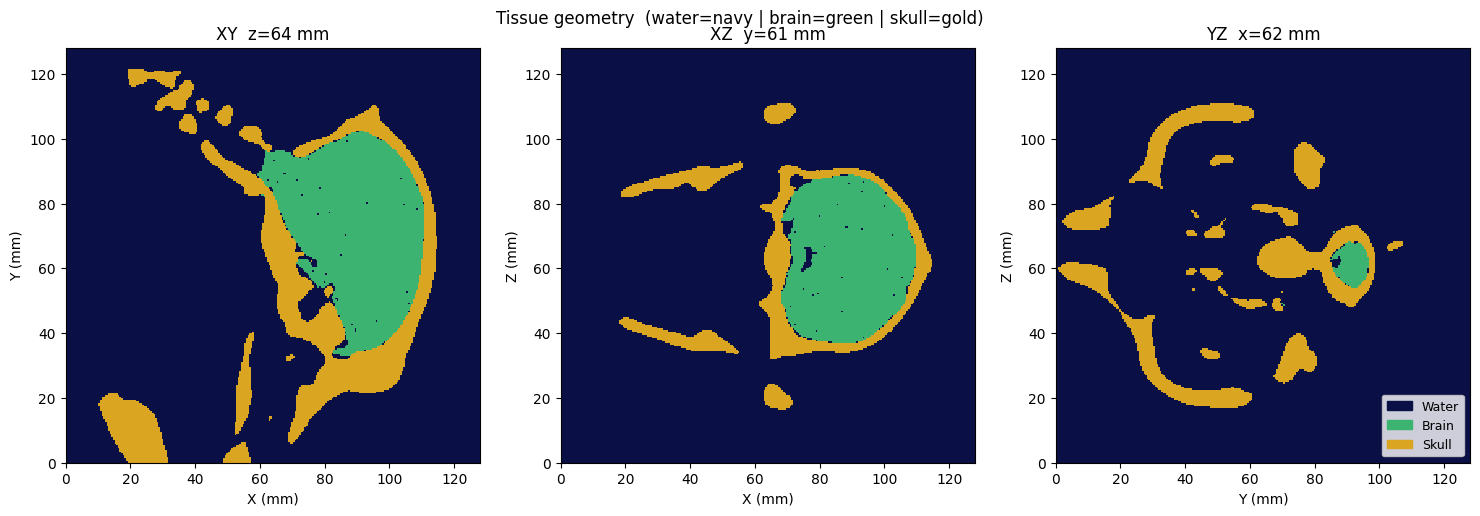

Saved geometry_2d.png


In [22]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

tissue = np.zeros(skull_pad.shape, dtype=np.uint8)
tissue[brain_pad] = 1
tissue[skull_pad] = 2

sk_idx = np.argwhere(skull_pad)
cxd = int((sk_idx[:,0].min() + sk_idx[:,0].max()) // 2)
cyd = int((sk_idx[:,1].min() + sk_idx[:,1].max()) // 2)
czd = int((sk_idx[:,2].min() + sk_idx[:,2].max()) // 2)

ex = [0, Nx*dx*1e3];  ey = [0, Ny*dx*1e3];  ez = [0, Nz*dx*1e3]

cmap3 = ListedColormap(['#0a1045', '#3cb371', '#daa520'])
kw    = dict(origin='lower', cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(tissue[:, :, czd].T, extent=ex+ey, **kw)
axes[0].set(title=f'XY  z={czd*dx*1e3:.0f} mm', xlabel='X (mm)', ylabel='Y (mm)')
axes[1].imshow(tissue[:, cyd, :].T, extent=ex+ez, **kw)
axes[1].set(title=f'XZ  y={cyd*dx*1e3:.0f} mm', xlabel='X (mm)', ylabel='Z (mm)')
im = axes[2].imshow(tissue[cxd, :, :].T, extent=ey+ez, **kw)
axes[2].set(title=f'YZ  x={cxd*dx*1e3:.0f} mm', xlabel='Y (mm)', ylabel='Z (mm)')
axes[2].legend(handles=[
    Patch(color='#0a1045', label='Water'),
    Patch(color='#3cb371', label='Brain'),
    Patch(color='#daa520', label='Skull'),
], loc='lower right', fontsize=9)

plt.suptitle('Tissue geometry  (water=navy | brain=green | skull=gold)', fontsize=12)
plt.tight_layout()
plt.savefig('geometry_2d.png', dpi=150)
plt.show()
print('Saved geometry_2d.png')

Extracting surfaces ...
Skull: 91,118 verts  182,830 faces
Brain: 22,463 verts  44,914 faces


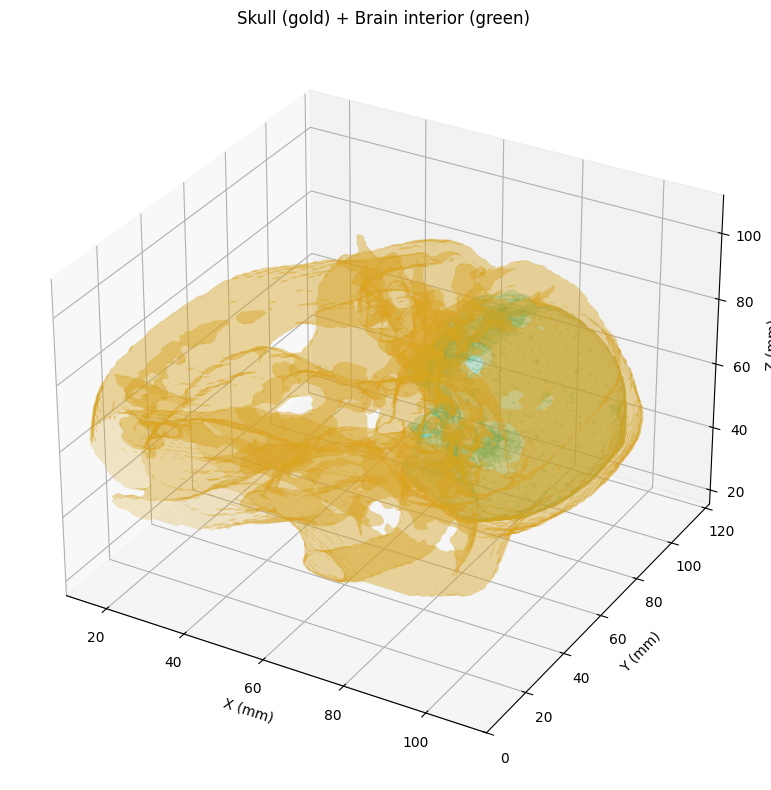

Saved geometry_3d.png


In [23]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def make_mesh(mask, step=2):
    v, f, _, _ = measure.marching_cubes(mask.astype(np.float32), level=0.5, step_size=step)
    return v * dx * 1e3, f   # verts in mm

print('Extracting surfaces ...')
sv, sf = make_mesh(skull_pad, step=2)
bv, bf = make_mesh(brain_pad, step=2)
print(f'Skull: {len(sv):,} verts  {len(sf):,} faces')
print(f'Brain: {len(bv):,} verts  {len(bf):,} faces')

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

skull_mesh = Poly3DCollection(sv[sf], alpha=0.25, linewidth=0)
skull_mesh.set_facecolor('goldenrod')
ax.add_collection3d(skull_mesh)

brain_mesh = Poly3DCollection(bv[bf], alpha=0.15, linewidth=0)
brain_mesh.set_facecolor('#3cb371')
ax.add_collection3d(brain_mesh)

all_v = np.vstack([sv, bv])
ax.set_xlim(all_v[:,0].min(), all_v[:,0].max())
ax.set_ylim(all_v[:,1].min(), all_v[:,1].max())
ax.set_zlim(all_v[:,2].min(), all_v[:,2].max())
ax.set_xlabel('X (mm)');  ax.set_ylabel('Y (mm)');  ax.set_zlabel('Z (mm)')
ax.set_title('Skull (gold) + Brain interior (green)')

plt.tight_layout()
plt.savefig('geometry_3d.png', dpi=150)
plt.show()
print('Saved geometry_3d.png')

## Step 4 — Build k-Wave Grid & Medium
Creates `kWaveGrid` matching the NIfTI voxel size exactly (no resampling).  
Fills `kWaveMedium` arrays with water → skull → brain in that priority order.

In [24]:
kgrid = kWaveGrid([Nx, Ny, Nz], [dx, dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)

print(f'Grid     : {Nx}×{Ny}×{Nz} = {Nx*Ny*Nz/1e6:.1f} M points')
print(f'Physical : {Nx*dx*1e3:.0f} × {Ny*dx*1e3:.0f} × {Nz*dx*1e3:.0f} mm')
print(f'dx       : {dx*1e3:.2f} mm  ({c_water/(dx*freq):.1f} pts/λ at {freq/1e3:.0f} kHz)')
print(f'dt       : {kgrid.dt:.3e} s   Nt = {kgrid.Nt}')

ss  = np.full((Nx, Ny, Nz), c_water,   dtype=np.float32)
rho = np.full((Nx, Ny, Nz), rho_water, dtype=np.float32)

ss[skull_pad]  = c_skull;   rho[skull_pad]  = rho_skull
ss[brain_pad]  = c_brain;   rho[brain_pad]  = rho_brain

medium = kWaveMedium(sound_speed=ss, density=rho)
print(f'\nMedium built  (sound speed range: {ss.min():.0f}–{ss.max():.0f} m/s)')

Grid     : 256×256×256 = 16.8 M points
Physical : 128 × 128 × 128 mm
dx       : 0.50 mm  (5.9 pts/λ at 500 kHz)
dt       : 5.172e-08 s   Nt = 1479

Medium built  (sound speed range: 1482–2900 m/s)


## Step 5 — Point Source & 3-Plane Sensor
Source: single point at brain centroid, 5-cycle 500 kHz tone burst at 100 kPa.  
Sensor: three orthogonal planes through source (~1.2 GB GPU vs ~99 GB for full volume).

In [25]:
brain_com = ndimage.center_of_mass(brain_pad)
sx = int(round(brain_com[0]))
sy = int(round(brain_com[1]))
sz = int(round(brain_com[2]))

assert brain_pad[sx, sy, sz], 'Source voxel not inside brain — check brain fill'

source = kSource()
source.p_mask = np.zeros((Nx, Ny, Nz), dtype=np.uint8)
source.p_mask[sx, sy, sz] = 1
burst = tone_burst(1 / kgrid.dt, freq, 5).flatten()
source.p = (burst * 1e5).reshape(1, -1)   # 100 kPa

sensor_mask = np.zeros((Nx, Ny, Nz), dtype=np.uint8)
sensor_mask[:, :, sz] = 1   # XY plane
sensor_mask[:, sy, :] = 1   # XZ plane
sensor_mask[sx, :, :] = 1   # YZ plane

sensor = kSensor()
sensor.mask   = sensor_mask
sensor.record = ['p_max']

n_pts  = int(sensor_mask.sum())
mem_GB = n_pts * kgrid.Nt * 4 / 1e9
print(f'Source  : voxel ({sx},{sy},{sz}) → ({sx*dx*1e3:.1f},{sy*dx*1e3:.1f},{sz*dx*1e3:.1f}) mm')
print(f'Burst   : {len(burst)} samples, 5 cycles, 100 kPa')
print(f'Sensor  : {n_pts:,} pts (3 planes)  ≈ {mem_GB:.2f} GB GPU')

Source  : voxel (176,143,124) → (88.0,71.5,62.0) mm
Burst   : 194 samples, 5 cycles, 100 kPa
Sensor  : 195,841 pts (3 planes)  ≈ 1.16 GB GPU


## Step 6 — Run Simulation (GPU)
Expected runtime: ~2–5 min for 256³ / 1479 steps on RTX 5070.

In [26]:
print('Running on GPU ...')
sd = kspaceFirstOrder(kgrid, medium, source, sensor,
                      device='gpu', dtype='float32')

p_max = np.zeros((Nx, Ny, Nz), dtype=np.float32)
p_max[sensor_mask.astype(bool)] = sd['p_max']

print(f'Peak pressure (3 planes) : {p_max.max()/1e3:.2f} kPa')

Running on GPU ...


k-Wave: 100%|██████████| 1479/1479 [17:14<00:00,  1.43step/s]


Peak pressure (3 planes) : 33.54 kPa


## Step 7 — Visualize Peak Pressure
Three sensor planes with skull contour (cyan) and source location (white +) overlaid.

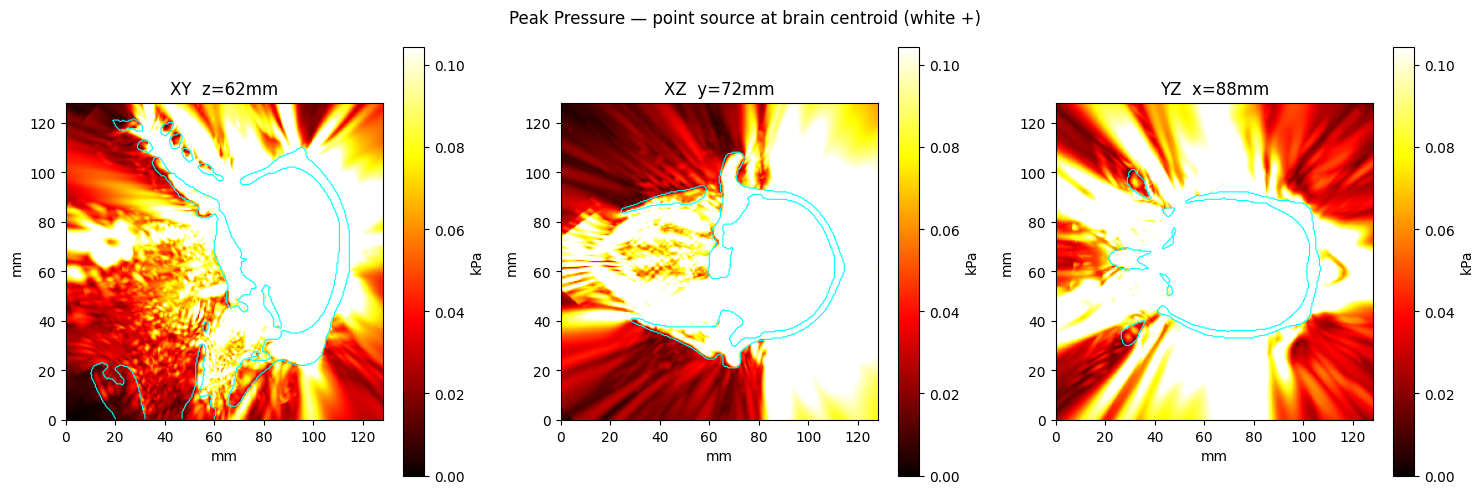

Saved pmax.png


In [27]:
vmax = np.percentile(p_max, 99.5) / 1e3
sx_mm = sx*dx*1e3;  sy_mm = sy*dx*1e3;  sz_mm = sz*dx*1e3

panels = [
    (p_max[:, :, sz].T/1e3, ex+ey, f'XY  z={sz_mm:.0f}mm', sx_mm, sy_mm, skull_pad[:, :, sz].T),
    (p_max[:, sy, :].T/1e3, ex+ez, f'XZ  y={sy_mm:.0f}mm', sx_mm, sz_mm, skull_pad[:, sy, :].T),
    (p_max[sx, :, :].T/1e3, ey+ez, f'YZ  x={sx_mm:.0f}mm', sy_mm, sz_mm, skull_pad[sx, :, :].T),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (data, ext, title, dotx, doty, sk_sl) in zip(axes, panels):
    im = ax.imshow(data, origin='lower', extent=ext, cmap='hot', vmin=0, vmax=vmax)
    ax.contour(sk_sl, levels=[0.5], colors='cyan', linewidths=0.8, extent=ext, origin='lower')
    ax.plot(dotx, doty, 'w+', ms=10, mew=1.5)
    ax.set(title=title, xlabel='mm', ylabel='mm')
    plt.colorbar(im, ax=ax, label='kPa')

plt.suptitle('Peak Pressure — point source at brain centroid (white +)', fontsize=12)
plt.tight_layout()
plt.savefig('pmax.png', dpi=150)
plt.show()
print('Saved pmax.png')